In [8]:
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Data import CodonTable
import os
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def read_gene_expression(file_path):
    """
    Read gene expression data with RNA-Seq RSEM normalized values

    Parameters:
    file_path (str): Path to gene expression file

    Returns:
    pandas.DataFrame: DataFrame with patient_id, sample_id and gene expression values
    """
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Gene expression data loaded: {df.shape[0]} samples, {df.shape[1]-2} genes")
    return df

def read_somatic_mutations(file_path):
    """
    Read somatic mutations data in MAF format

    Parameters:
    file_path (str): Path to mutation annotation file
    2`x
    Returns:
    pandas.DataFrame: DataFrame with mutation information
    """
    # Read the tab-separated MAF file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Somatic mutations data loaded: {df.shape[0]} mutations")
    return df

def read_patient_metadata(file_path):
    """
    Read patient clinical and pathological metadata

    Parameters:
    file_path (str): Path to patient metadata file

    Returns:
    pandas.DataFrame: DataFrame with patient clinical information
    """
    # Read the tab-separated metadata file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Patient metadata loaded: {df.shape[0]} patients")
    return df

def explore_data(gene_expr, somatic_mut, patient_meta):
    """
    Basic exploration of the three datasets
    """
    # Explore patient metadata
    print("\nPatient demographics:")
    print(f"Gender distribution:\n{patient_meta['gender'].value_counts()}")
    print(f"Age statistics:\n{patient_meta['age_at_initial_pathologic_diagnosis'].describe()}")

    # Analyze survival data
    print("\nSurvival statistics:")
    print(f"Overall survival events: {patient_meta['OS'].sum()} deaths out of {patient_meta['OS'].count()} patients")

    # Look at mutations per patient
    if 'patient_id' in somatic_mut.columns:
        mutations_per_patient = somatic_mut['patient_id'].value_counts()
        print(f"\nMutations per patient statistics:")
        print(mutations_per_patient.describe())

    # For gene expression, we could look at the most variable genes
    if gene_expr is not None and gene_expr.shape[1] > 2:
        print("\nGene expression statistics:")
        gene_columns = gene_expr.columns[2:]  # Skipping patient_id and sample_id
        gene_variance = gene_expr[gene_columns].var().sort_values(ascending=False)
        print(f"Top 5 most variable genes:\n{gene_variance.head(5)}")

gene_expression_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.expression.txt')
somatic_mutations_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.mutations.txt')
metadata_path = os.path.join(os.getcwd(),'Team_4_STAD', 'TCGA.STAD.metadata.txt')

gene_expr = read_gene_expression(gene_expression_path)
somatic_mut = read_somatic_mutations(somatic_mutations_path)
patient_meta = read_patient_metadata(metadata_path)

# explore_data(gene_expr, somatic_mut, patient_meta)


patient_meta['OS']      = pd.to_numeric(patient_meta['OS'], errors='coerce')
patient_meta['OS.time'] = pd.to_numeric(patient_meta['OS.time'], errors='coerce')

# 2. drop NaN
patient_meta = patient_meta.dropna(subset=['OS', 'OS.time'])

# 3. check categorical NaN
print("Before categorical clean:\n", patient_meta[['gender','ajcc_pathologic_tumor_stage','histological_grade']].isnull().sum())

patient_meta = patient_meta.dropna(subset=['gender','ajcc_pathologic_tumor_stage','histological_grade'])

print("After categorical clean:\n", patient_meta[['gender','ajcc_pathologic_tumor_stage','histological_grade']].isnull().sum())

patient_meta = patient_meta.reset_index(drop=True)

Gene expression data loaded: 447 samples, 20531 genes
Somatic mutations data loaded: 234941 mutations
Patient metadata loaded: 415 patients
Before categorical clean:
 gender                         0
ajcc_pathologic_tumor_stage    0
histological_grade             0
dtype: int64
After categorical clean:
 gender                         0
ajcc_pathologic_tumor_stage    0
histological_grade             0
dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column ajcc_pathologic_tumor_stage_Stage III have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['OS'].astype(bool)
>>> print(df.loc[events, 'ajcc_pathologic_tumor_stage_Stage III'].var())
>>> print(df.loc[~events, 'ajcc_pathologic_tumor_stage_Stage III'].var())

A very low variance means that the column ajcc_pathologic_tumor_stage_Stage III completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.

<lifelines.CoxPHFitter: fitted with 406 total observations, 249 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
      baseline estimation = breslow
   number of observations = 406
number of events observed = 157
   partial log-likelihood = -800.80
         time fit was run = 2025-05-28 00:19:33 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
age_at_initial_pathologic_diagnosis          0.03      1.03      0.01            0.01            0.05                1.01                1.05
gender_MALE                                  0.20      1.22      0.18           -0.15            0.54                0.86                1.72
ajcc_pathologic_tumor_stage_Stage IA        12.42  2.47e+05   1634.36        -3190.86         3215.70                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IB        13.16  5.19e+05   1634.36        -3190.12         3216.44                0.00                 inf
ajcc_pathologic_tumor_stage_Stage II        13.49  7.25e+05   1634.36        -3189.78         3216.77                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIA       13.32  6.09e+05   1634.36        -3189.96         3216.60                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIB       13.51  7.33e+05   1634.36        -3189.77         3216.78                0.00                 inf
ajcc_pathologic_tumor_stage_Stage III       15.31  4.45e+06   1634.36        -3187.97         3218.59                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIIA      13.90  1.09e+06   1634.36        -3189.37         3217.18                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIIB      13.75  9.39e+05   1634.36        -3189.52         3217.03                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IIIC      14.06  1.27e+06   1634.36        -3189.22         3217.33                0.00                 inf
ajcc_pathologic_tumor_stage_Stage IV        14.76  2.57e+06   1634.36        -3188.52         3218.04                0.00                 inf
ajcc_pathologic_tumor_stage_[Discrepancy]   14.33  1.68e+06   1634.36        -3188.95         3217.61                0.00                 inf
ajcc_pathologic_tumor_stage_[Not Available] 15.16  3.84e+06   1634.36        -3188.12         3218.44                0.00                 inf
histological_grade_G2                        0.30      1.35      0.64           -0.95            1.55                0.39                4.70
histological_grade_G3                        0.74      2.09      0.64           -0.51            1.99                0.60                7.28
histological_grade_GX                        1.17      3.23      0.81           -0.41            2.76                0.66               15.80

                                             cmp to    z      p  -log2(p)
covariate                                                                
age_at_initial_pathologic_diagnosis            0.00 3.47 <0.005     10.91
gender_MALE                                    0.00 1.12   0.26      1.93
ajcc_pathologic_tumor_stage_Stage IA           0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage IB           0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage II           0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage IIA          0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage IIB          0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage III          0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage IIIA         0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage IIIB         0.00 0.01   0.99      0.01
ajcc_pathologic_tumor_stage_Stage IIIC         0.00 0.01

   test_statistic         p  -log2(p)
0        0.025865  0.872229  0.197221


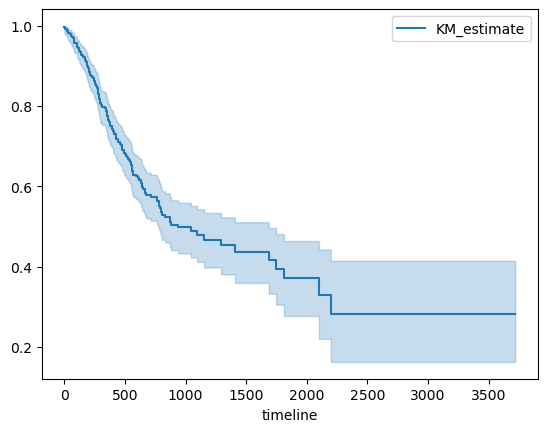

In [9]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:
    """
    Handle missing data by dropping or filling NaN values.

    Parameters:
    df (pd.DataFrame): The DataFrame to process.
    subset_cols (list): If provided, only consider these cols when dropping NaNs.
    method (str): "drop" to drop NaNs, "fill" to fill numeric cols with their mean.

    Returns:
    pd.DataFrame: Cleaned DataFrame.
    """
    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'OS.time',
                          event_col: str = 'OS') -> KaplanMeierFitter:
    """
    Fit and plot a Kaplan–Meier curve on OS.time / OS.
    """
    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:
    """
    Fit a Cox Proportional Hazards model.
    """
    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    cph.print_summary()
    return cph

def logrank_test_between_groups(df: pd.DataFrame,
                                group_col: str,
                                group1,
                                group2,
                                time_col: str = 'OS.time',
                                event_col: str = 'OS'):
    """
    Perform log-rank test comparing two subgroups.
    """
    def clean(sub: pd.DataFrame):
        tmp = sub[[time_col, event_col]].copy()
        tmp[time_col] = pd.to_numeric(tmp[time_col], errors='coerce')
        tmp[event_col] = pd.to_numeric(tmp[event_col], errors='coerce')
        return handle_missing_data(tmp, subset_cols=[time_col, event_col], method="drop")
    g1 = clean(df[df[group_col] == group1])
    g2 = clean(df[df[group_col] == group2])
    if g1.empty or g2.empty:
        raise ValueError("One group is empty after cleaning")
    res = logrank_test(
        g1[time_col],
        g2[time_col],
        event_observed_A=g1[event_col],
        event_observed_B=g2[event_col]
    )
    print(res.summary)
    return res

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:
    """
    Add `mutation_status` = 'mutant' if Hugo_Symbol == mutation_gene else 'wildtype'.
    """
    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df

# 1) mark mutation status
somatic_mut = add_mutation_status_column(somatic_mut, 'Hugo_Symbol', 'TP53')
#  metadata
patient_meta = patient_meta.copy()
patient_meta['mutation_status'] = np.where(
    patient_meta['patient_id'].isin(
        somatic_mut[somatic_mut['mutation_status']=='mutant']['patient_id']),
    'mutant', 'wildtype'
)

# 2) Kaplan–Meier
kmf = kaplan_meier_survival(patient_meta)

# 3) CoxPH 
numeric = ['age_at_initial_pathologic_diagnosis']
categorical = ['gender', 'ajcc_pathologic_tumor_stage', 'histological_grade']
cph = cox_proportional_hazards(patient_meta,
                               time_col='OS.time',
                               event_col='OS',
                               numeric_covs=numeric,
                               categorical_covs=categorical)

# 4) Log-rank: mutant vs. wildtype
lr = logrank_test_between_groups(patient_meta,
                                 group_col='mutation_status',
                                 group1='mutant',
                                 group2='wildtype')


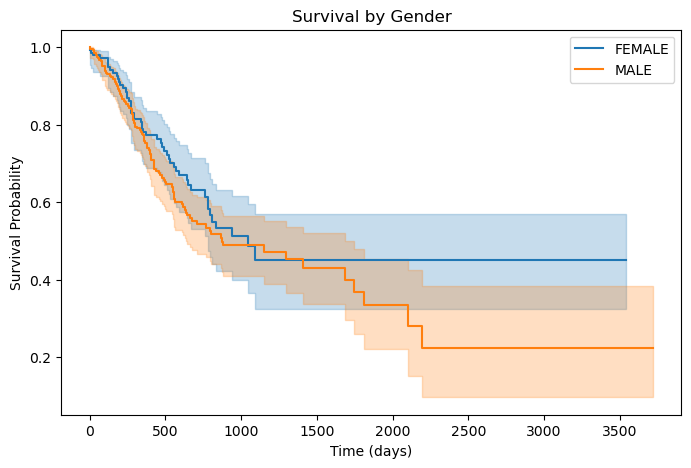

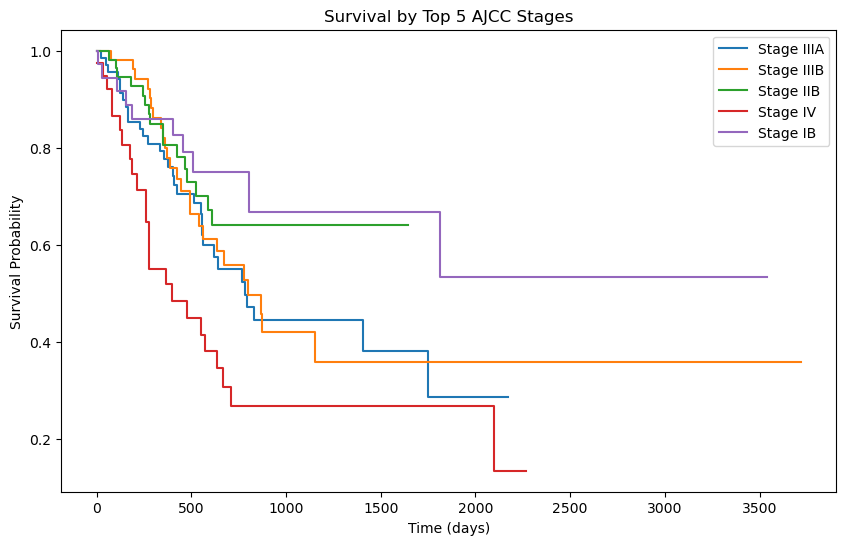

/opt/anaconda3/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column ajcc_pathologic_tumor_stage_Stage III have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['OS'].astype(bool)
>>> print(df.loc[events, 'ajcc_pathologic_tumor_stage_Stage III'].var())
>>> print(df.loc[~events, 'ajcc_pathologic_tumor_stage_Stage III'].var())

A very low variance means that the column ajcc_pathologic_tumor_stage_Stage III completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.

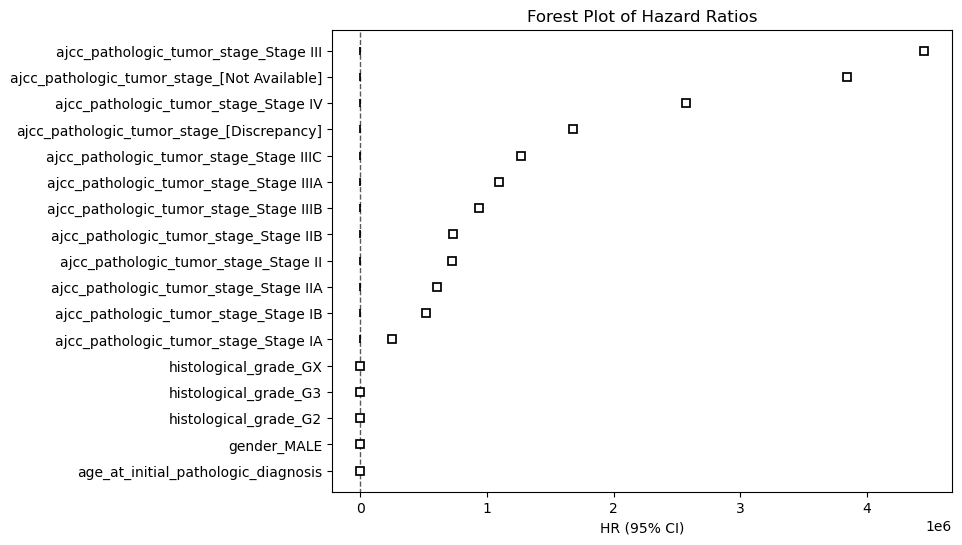

In [10]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

#—— 1) Kaplan–Meier by gender ——#
kmf = KaplanMeierFitter()
plt.figure(figsize=(8,5))
for grp, sub in patient_meta.groupby('gender'):
    kmf.fit(sub['OS.time'], event_observed=sub['OS'], label=grp)
    kmf.plot_survival_function(ci_show=True)
plt.title("Survival by Gender")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

#—— 2) Kaplan–Meier by AJCC stages ——#
plt.figure(figsize=(10,6))
top_stages = patient_meta['ajcc_pathologic_tumor_stage'].value_counts().index[:5]
for stage in top_stages:
    sub = patient_meta[patient_meta['ajcc_pathologic_tumor_stage']==stage]
    kmf.fit(sub['OS.time'], event_observed=sub['OS'], label=stage)
    kmf.plot_survival_function(ci_show=False)
plt.title("Survival by Top 5 AJCC Stages")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

#—— 3) Forest Plot of Hazard Ratios ——#
numeric = ['age_at_initial_pathologic_diagnosis']
categorical = ['gender', 'ajcc_pathologic_tumor_stage', 'histological_grade']
df = patient_meta[['OS.time','OS'] + numeric + categorical].copy()
df['OS.time'] = pd.to_numeric(df['OS.time'], errors='coerce')
df['OS']      = pd.to_numeric(df['OS'], errors='coerce')
df = df.dropna(subset=['OS.time','OS'] + numeric)
df = pd.get_dummies(df, columns=categorical, drop_first=True)
cph = CoxPHFitter()
cph.fit(df, duration_col='OS.time', event_col='OS')

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("Forest Plot of Hazard Ratios")
plt.show()
